# Value of Information Analysis: van Zwet (2026) OSC Corpus

We demonstrate how to calculate the value of information of several different proxy signals and latent epistemic states within a Bayesian decision-theoretic framework.  We use the signal-to-noise ratio mixture
model of van Zwet, Gelman & Więcek (2026) fit to the Open Science Collaboration (OSC)
psychology replication corpus (100 studies), to provide the latent signal-to-noise ratios from which proxies and latent states are produced.

## Decision problem

We assume a reviewer choosing between two actions: **flag** a claim for evidential fragility, or
**do not flag** it. We use a symmetric 0/1 utility, where the correct decision is worth 1, and the incorrect decision is worth 0.
Expected utility is thus equal to the probability of a correct decision.

## Latent epistemic states

- $\theta_\mathrm{sign} = \mathbf{1}(\Lambda Z > 0)$: the observed effect has the correct sign
- $\theta_\mathrm{snr} = \mathbf{1}(|\Lambda| \ge \lambda_0)$: the study has sufficient SNR

To define sufficient SNF, we use a default threshold of **$\lambda_0 = 2.8,$** which is the SNR needed for 80% power at the 5% two-sided level. However, we also include a less stringest threshold of **$\lambda_0 = 1.96$** for comparison, which is the SNR needed for 50% power.

## Signals

- $S_\mathrm{sig} = \mathbf{1}(|Z| \ge 1.96)$ — statistical significance
- $S_\mathrm{rep} = \mathbf{1}(Z Z_\mathrm{rep} > 0,\ |Z_\mathrm{rep}| \ge 1.96)$ — exact replication success

## Value of information quantities

For signal $S$:
$$V(\theta; S) = \mathbb{E}_S\bigl[\max\{P(\theta=1\mid S),\, P(\theta=0\mid S)\}\bigr], \qquad \Delta(\theta; S) = V(\theta; S) - V_0(\theta)$$
where $V_0(\theta) = \max\{P(\theta=1), P(\theta=0)\}$ is the no-signal baseline.

## Signal-to-noise model

$\Lambda \sim H$ (3-component symmetric mixture of normals), $Z = \Lambda + \varepsilon$,
$\varepsilon \sim \mathcal{N}(0,1)$. Replication: $Z_\mathrm{rep} = \Lambda + \varepsilon'$,
independent of $Z$ given $\Lambda$. Parameters from the
[BEAR GitHub repository](https://github.com/wwiecek/BEAR/).

In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## 1. Prior on SNR: OSC Corpus Parameters

Prior on $\Lambda$: symmetric 3-component mixture $H = \sum_k p_k\, \mathcal{N}(0, \sigma_{\mathrm{SNR},k}^2)$.
Observed $z$-values: $\sum_k p_k\, \mathcal{N}(0, \sigma_{z,k}^2)$ where $\sigma_{z,k}^2 = \sigma_{\mathrm{SNR},k}^2 + 1$.

In [2]:
# OSC corpus: fitted 4-component mixture from van Zwet et al. (2026) / BEAR repo
# Component 4 (sigma_SNR≈2252) excluded; its mass redistributed proportionally across components 1-3
p_mix_orig = np.array([0.390982, 0.112415, 0.486510, 0.010093])
ssnr_orig  = np.array([0.446322, 8.251094, 2.436323, 2251.593835])
sz_mix_orig = np.array([1.095082, 8.311471, 2.633566, 2251.594057])

p_mix  = p_mix_orig[:3] / p_mix_orig[:3].sum()    # mixture weights
ssnr   = ssnr_orig[:3]                             # sigma_SNR per component
sz_mix = sz_mix_orig[:3]                           # sigma_z   per component

# SNR thresholds to evaluate
# lambda_0 = 2.8 → 80% power (primary analysis)
# lambda_0 = 1.96 → 50% power (sensitivity / equals significance threshold)
lam0s = [2.8, 1.96]

print("Component weights and sigmas:")
print(f"{'k':>3}  {'p_k':>9}  {'sigma_SNR':>12}  {'sigma_z':>12}")
for k in range(3):
    print(f"{k+1:>3}  {p_mix[k]:>9.6f}  {ssnr[k]:>12.6f}  {sz_mix[k]:>12.6f}")
print(f"\nSNR thresholds: {lam0s}")

Component weights and sigmas:
  k        p_k     sigma_SNR       sigma_z
  1   0.394968      0.446322      1.095082
  2   0.113561      8.251094      8.311471
  3   0.491470      2.436323      2.633566

SNR thresholds: [2.8, 1.96]


## 2. Integration Grids

We compute all posteriors and expectations by numerical integration over discrete grids. The prior $h(\lambda)$ and the marginal $f(z)$ are evaluated on uniform grids over $[-30, 30]$ — a range that captures $>99.97%$ of the probability for all components. Integrals like $\int p(\lambda \mid z), d\lambda$ are then approximated as weighted sums over the grid. The loop processes 200 $z$-values at a time to limit peak memory.

In [3]:
lam_grid = np.linspace(-30, 30, 2001);  dl = lam_grid[1] - lam_grid[0]
z_grid   = np.linspace(-30, 30, 4001);  dz = z_grid[1]   - z_grid[0]

# Prior density h(lambda), renormalized to the grid
h = np.sum(p_mix[:,None] * stats.norm.pdf(lam_grid[None,:], 0, ssnr[:,None]), axis=0)
h /= h.sum() * dl

# Marginal density of Z, renormalized to the grid
fz = np.sum(p_mix[:,None] * stats.norm.pdf(z_grid[None,:], 0, sz_mix[:,None]), axis=0)
fz /= fz.sum() * dz

# SNR threshold indicators on lambda grid (one per threshold)
hs_lams = [(np.abs(lam_grid) >= lam0).astype(float) for lam0 in lam0s]

print(f"Grid spacings: dlambda={dl:.4f}, dz={dz:.4f}")

Grid spacings: dlambda=0.0300, dz=0.0150


### Prior and marginal distributions

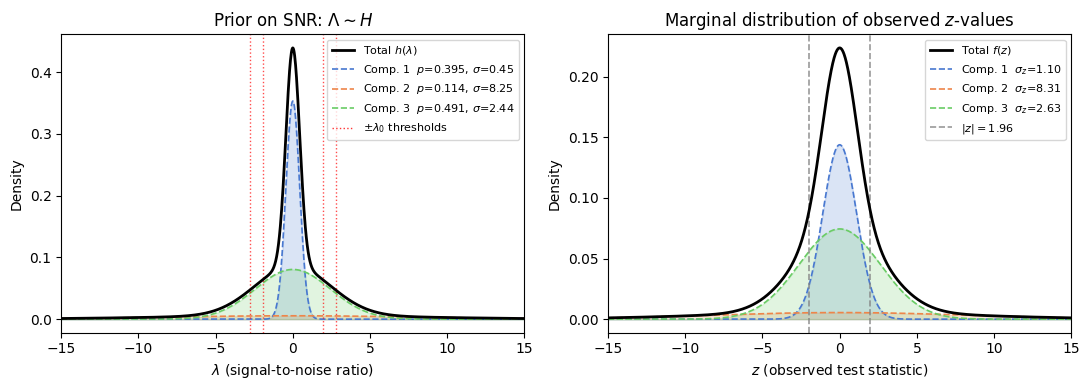

In [4]:
colors = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']
visible = list(range(len(p_mix)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: Prior h(lambda) — SNR distribution
ax = axes[0]
ax.plot(lam_grid, h, 'k-', lw=2, label='Total $h(\\lambda)$', zorder=5)
for k in visible:
    comp = p_mix[k] * stats.norm.pdf(lam_grid, 0, ssnr[k])
    ax.fill_between(lam_grid, comp, alpha=0.2, color=colors[k])
    ax.plot(lam_grid, comp, '--', lw=1.2, color=colors[k],
            label=f'Comp. {k+1}  $p$={p_mix[k]:.3f}, $\\sigma$={ssnr[k]:.2f}')
for lam0 in lam0s:
    ax.axvline( lam0, color='red', lw=1, ls=':', alpha=0.7)
    ax.axvline(-lam0, color='red', lw=1, ls=':', alpha=0.7)
ax.plot([], [], color='red', lw=1, ls=':', alpha=0.8, label='$\\pm\\lambda_0$ thresholds')
ax.set_xlim(-15, 15)
ax.set_xlabel('$\\lambda$ (signal-to-noise ratio)')
ax.set_ylabel('Density')
ax.set_title('Prior on SNR: $\\Lambda \\sim H$')
ax.legend(fontsize=8)

# Right: Marginal f(z) — distribution of observed z-values
ax = axes[1]
ax.plot(z_grid, fz, 'k-', lw=2, label='Total $f(z)$', zorder=5)
for k in visible:
    comp = p_mix[k] * stats.norm.pdf(z_grid, 0, sz_mix[k])
    ax.fill_between(z_grid, comp, alpha=0.2, color=colors[k])
    ax.plot(z_grid, comp, '--', lw=1.2, color=colors[k],
            label=f'Comp. {k+1}  $\\sigma_z$={sz_mix[k]:.2f}')
ax.axvline( 1.96, color='gray', lw=1.2, ls='--', alpha=0.8, label='$|z|=1.96$')
ax.axvline(-1.96, color='gray', lw=1.2, ls='--', alpha=0.8)
ax.set_xlim(-15, 15)
ax.set_xlabel('$z$ (observed test statistic)')
ax.set_ylabel('Density')
ax.set_title('Marginal distribution of observed $z$-values')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Grid-Based Posterior Computation

For each $z$ on the grid we compute:
1. Posterior $p(\lambda \mid z) \propto \phi(z-\lambda)\, h(\lambda)$
2. Replication likelihood $L_1(\lambda,z) = P(S_\mathrm{rep}=1\mid\lambda,z) = \Phi(\mathrm{sign}(z)\cdot\lambda - 1.96)$
3. Posteriors given $S_\mathrm{rep}=1$ or $0$
4. Posterior $P(\theta=1\mid z)$ and $P(\theta=1\mid z, S_\mathrm{rep})$ for each state — intermediate quantities, marginalized over $z$ in Section 5 to give $P(\theta=1\mid S_\mathrm{sig})$ and $P(\theta=1\mid S_\mathrm{sig}, S_\mathrm{rep})$

Both $\theta_\mathrm{sign}$ and $S_\mathrm{rep}$ quantities do not depend on the threshold, so we compute those once.
$\theta_\mathrm{snr}$ quantities are computed simultaneously for both thresholds.

In [5]:
# Intermediate arrays indexed over z_grid; marginalized in Section 5 to give signal-based posteriors
P_sign_z  = np.zeros(len(z_grid))   # P(theta_sign=1 | z)
P_srep1_z = np.zeros(len(z_grid))   # P(S_rep=1 | z)
Ps_z1     = np.zeros(len(z_grid))   # P(theta_sign=1 | z, S_rep=1)
Ps_z0     = np.zeros(len(z_grid))   # P(theta_sign=1 | z, S_rep=0)

# theta_snr arrays: first axis indexes the two thresholds
P_snr_z = np.zeros((2, len(z_grid)))
Pn_z1   = np.zeros((2, len(z_grid)))  # P(theta_snr=1 | z, S_rep=1)
Pn_z0   = np.zeros((2, len(z_grid)))  # P(theta_snr=1 | z, S_rep=0)

CHUNK = 200
for start in range(0, len(z_grid), CHUNK):
    zc = z_grid[start:start+CHUNK]; nc = len(zc)
    zs = np.sign(zc); zs[zs==0] = 1.0  # sign of z

    # Posterior p(lambda | z)
    lik  = stats.norm.pdf(zc[:,None] - lam_grid[None,:])  # (nc, n_lam)
    post = h[None,:] * lik
    post /= post.sum(axis=1, keepdims=True) * dl

    # P(S_rep=1 | lambda, z) = Phi(sign(z)*lambda - 1.96)
    L1   = stats.norm.cdf(zs[:,None] * lam_grid[None,:] - 1.96)
    raw1 = post * L1;       ps1 = raw1.sum(axis=1) * dl   # P(S_rep=1 | z)
    raw0 = post * (1 - L1); ps0 = raw0.sum(axis=1) * dl   # P(S_rep=0 | z), computed directly
    # ps0 must be computed from raw0, NOT as (1-ps1): catastrophic cancellation
    # when ps1≈1 (large |z|), 1-ps1 underflows to 0 in float64 while raw0 is still finite.
    post1 = raw1 / np.maximum(ps1[:,None], 1e-300)         # p(lam | z, S_rep=1)
    post0 = raw0 / np.maximum(ps0[:,None], 1e-300)         # p(lam | z, S_rep=0)

    # theta_sign: correct sign means lambda*sign(z) > 0
    cs_mat = (zs[:,None] * lam_grid[None,:] > 0).astype(float)
    P_sign_z[start:start+nc]  = (post  * cs_mat).sum(1) * dl
    P_srep1_z[start:start+nc] = ps1
    Ps_z1[start:start+nc]     = np.clip((post1 * cs_mat).sum(1) * dl, 0, 1)
    Ps_z0[start:start+nc]     = np.clip((post0 * cs_mat).sum(1) * dl, 0, 1)

    # theta_snr: computed for each threshold
    for i, hsl in enumerate(hs_lams):
        P_snr_z[i, start:start+nc] = (post  * hsl).sum(1) * dl
        Pn_z1[i,   start:start+nc] = np.clip((post1 * hsl).sum(1) * dl, 0, 1)
        Pn_z0[i,   start:start+nc] = np.clip((post0 * hsl).sum(1) * dl, 0, 1)

print("Grid computation complete.")

Grid computation complete.


In [6]:
dV = 0.0
print(f"dV = {dV}")

dV = 0.0


## 5. VOI Computation

The below function computes all VOI quantities for a given latent state,
using its posterior probability arrays and the shared signal marginals.

In [7]:
def integrate(arr):
    return (arr * fz).sum() * dz

# Shared signal marginals (same for all theta states and thresholds)
sig_mask = np.abs(z_grid) >= 1.96
p_rep1   = integrate(P_srep1_z) + dV
p_rep0   = 1 - p_rep1
p_sig1   = integrate(sig_mask.astype(float)) + dV
p_sig0   = 1 - p_sig1

def compute_voi(Pz, Pz1, Pz0, label):
    """Compute all VOI quantities for a theta state.
    Pz  = P(theta=1 | z)  over z_grid
    Pz1 = P(theta=1 | z, S_rep=1) over z_grid
    Pz0 = P(theta=1 | z, S_rep=0) over z_grid
    """
    P0 = integrate(Pz) + dV
    V0 = max(P0, 1 - P0)


    # V_sig: observe I(|z|>=1.96)
    pt1s = (integrate(Pz * sig_mask) + dV) / p_sig1   # P(theta=1 | S_sig=1)
    pt0s =  integrate(Pz * ~sig_mask)      / p_sig0   # P(theta=1 | S_sig=0)
    Vsig = p_sig1*max(pt1s, 1-pt1s) + p_sig0*max(pt0s, 1-pt0s)

    # V_rep: observe S_rep only
    pt1r = (integrate(Pz1 * P_srep1_z) + dV) / p_rep1
    pt0r =  integrate(Pz0 * (1-P_srep1_z))   / p_rep0
    Vrep = p_rep1*max(pt1r, 1-pt1r) + p_rep0*max(pt0r, 1-pt0r)


    # V_(sig, rep): observe (S_sig, S_rep)
    Vsrep = 0
    for sm, is_sig in [(~sig_mask, False), (sig_mask, True)]:
        for Pzr, Pr_z, is_rep in [(Pz0, 1-P_srep1_z, False), (Pz1, P_srep1_z, True)]:
            extra = dV if (is_sig and is_rep) else 0.0
            denom = integrate(sm.astype(float) * Pr_z) + extra
            if denom < 1e-10: continue
            pt1 = (integrate(Pzr * sm * Pr_z) + extra) / denom
            Vsrep += denom * max(pt1, 1-pt1)

    return dict(label=label, P0=P0, V0=V0, Vsig=Vsig, Vrep=Vrep,
                Vsrep=Vsrep)

print("VOI functions defined.")

VOI functions defined.


## 6. Results

In [8]:
res_sign = compute_voi(P_sign_z, Ps_z1, Ps_z0, "theta_sign (any threshold)")
res_snr  = [compute_voi(P_snr_z[i], Pn_z1[i], Pn_z0[i],
                        f"theta_snr (lambda_0={lam0s[i]}, {'80' if lam0s[i]==2.8 else '50'}% power)")
            for i in range(2)]

def results_table(r):
    V0, Vsig, Vrep, Vsrep = r['V0'], r['Vsig'], r['Vrep'], r['Vsrep']
    rows = [
        ("V0",             V0,    None),
        ("V_sig",          Vsig,  Vsig  - V0),
        ("V_rep",          Vrep,  Vrep  - V0),
        ("V_(sig,rep)",    Vsrep, Vsrep - Vsig),
    ]
    return pd.DataFrame(
        [(n, f"{v:.4f}", f"{d:+.4f}" if d is not None else "") for n,v,d in rows],
        columns=["Quantity", "V", "Delta"]
    ).set_index("Quantity")

for r in [res_sign] + res_snr:
    print(f"\n{'='*55}")
    print(f"  {r['label']}")
    print(f"  P(theta=1) = {r['P0']:.4f}")
    print(f"{'='*55}")
    print(results_table(r).to_string())


  theta_sign (any threshold)
  P(theta=1) = 0.7834
                  V    Delta
Quantity                    
V0           0.7834         
V_sig        0.7834  +0.0000
V_rep        0.7834  +0.0000
V_(sig,rep)  0.7834  +0.0000

  theta_snr (lambda_0=2.8, 80% power)
  P(theta=1) = 0.2060
                  V    Delta
Quantity                    
V0           0.7940         
V_sig        0.8429  +0.0489
V_rep        0.8617  +0.0677
V_(sig,rep)  0.9252  +0.0823

  theta_snr (lambda_0=1.96, 50% power)
  P(theta=1) = 0.2985
                  V    Delta
Quantity                    
V0           0.7015         
V_sig        0.8713  +0.1698
V_rep        0.8887  +0.1872
V_(sig,rep)  0.9130  +0.0417


In [9]:
# Monotonicity checks: more information should never decrease expected utility
print("=== Monotonicity checks ===")
all_pass = True
for r in [res_sign] + res_snr:
    V0, Vsig, Vrep, Vsrep = r['V0'], r['Vsig'], r['Vrep'], r['Vsrep']
    checks = [
        ("V_(sig,rep) >= V_sig",Vsrep - Vsig),
        ("V_(sig,rep) >= V_rep", Vsrep - Vrep),
    ]
    print(f"\n  {r['label']}")
    for label, diff in checks:
        ok = diff >= -1e-4
        if not ok: all_pass = False
        print(f"    {label}: {diff:+.5f}  {'OK' if ok else 'FAIL'}")
print(f"\nAll checks passed: {all_pass}")

=== Monotonicity checks ===

  theta_sign (any threshold)
    V_(sig,rep) >= V_sig: +0.00000  OK
    V_(sig,rep) >= V_rep: +0.00000  OK

  theta_snr (lambda_0=2.8, 80% power)
    V_(sig,rep) >= V_sig: +0.08233  OK
    V_(sig,rep) >= V_rep: +0.06353  OK

  theta_snr (lambda_0=1.96, 50% power)
    V_(sig,rep) >= V_sig: +0.04170  OK
    V_(sig,rep) >= V_rep: +0.02426  OK

All checks passed: True


## 7. Verification

Cross-check key marginal statistics against values reported in van Zwet et al. (2026).

In [10]:
print("Verification against van Zwet et al. (2026) reported statistics:")
print(f"  P(theta_sign=1) = {res_sign['P0']:.4f}  [paper: 0.793]")
print(f"  P(sig=1)        = {p_sig1:.4f}  [paper: 0.351]")
print(f"  P(S_rep=1)      = {p_rep1:.4f}  [paper: 0.334]")

Verification against van Zwet et al. (2026) reported statistics:
  P(theta_sign=1) = 0.7834  [paper: 0.793]
  P(sig=1)        = 0.3463  [paper: 0.351]
  P(S_rep=1)      = 0.3273  [paper: 0.334]


## 8. VOI Benchmarks by Signal

Each panel shows one latent state. The dashed line is $V_0$ (no-signal baseline).
Dots show $V(\theta; S)$ for each signal; stems show $\Delta = V - V_0$; the dotted
line is $V_{(S_\mathrm{sig},\,S_\mathrm{rep})}$ (ceiling with both signals available).

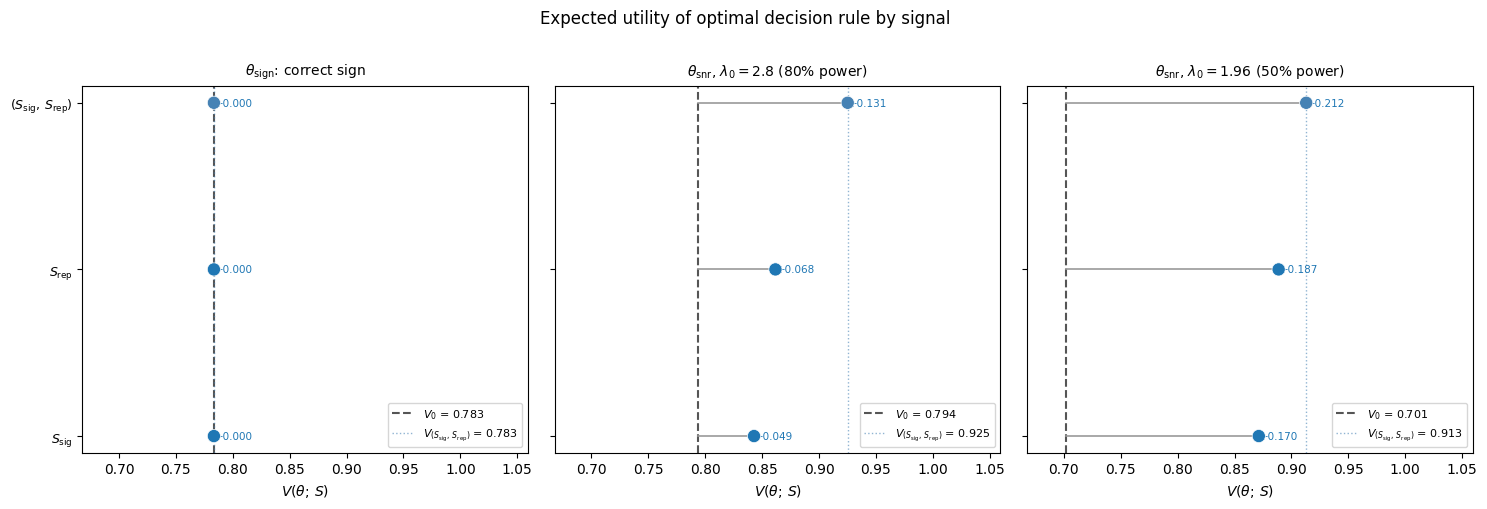

In [11]:
signal_labels = [
    '$S_\\mathrm{sig}$',
    '$S_\\mathrm{rep}$',
    '$(S_\\mathrm{sig},\\,S_\\mathrm{rep})$',
]
y = np.arange(len(signal_labels))

panel_titles = [
    '$\\theta_\\mathrm{sign}$: correct sign',
    '$\\theta_\\mathrm{snr}$, $\\lambda_0 = 2.8$ (80% power)',
    '$\\theta_\\mathrm{snr}$, $\\lambda_0 = 1.96$ (50% power)',
]

# Compute shared x-axis limits across all panels
all_results = [res_sign] + res_snr
all_vals = [v for r in all_results for v in [r['V0'], r['Vsig'], r['Vrep'], r['Vsrep']]]
x_margin = (max(all_vals) - min(all_vals)) * 0.15
x_min = min(all_vals) - x_margin
x_max = max(all_vals) + (max(all_vals) - min(all_vals)) * 0.6

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, r, title in zip(axes, all_results, panel_titles):
    V0    = r['V0']
    vals  = [r['Vsig'], r['Vrep'], r['Vsrep']]

    # Baseline (dashed) and ceiling (dotted) as vertical reference lines
    ax.axvline(V0,    color='#555', lw=1.5, ls='--', zorder=1,
               label=f'$V_0$ = {V0:.3f}')
    ax.axvline(r['Vsrep'], color='steelblue', lw=1, ls=':', alpha=0.6, zorder=1,
               label=f'$V_{{(S_{{\\mathrm{{sig}}}},\\,S_{{\\mathrm{{rep}}}})}}$ = {r["Vsrep"]:.3f}')

    # Horizontal lollipop stems from V0
    for yi, vi in zip(y, vals):
        ax.plot([V0, vi], [yi, yi], color='#999', lw=1.2, zorder=2)

    # Dots
    dot_colors = ['#1f77b4'] * (len(vals) - 1) + ['steelblue']
    ax.scatter(vals, y, color=dot_colors, s=90, zorder=4, edgecolors='white', linewidths=0.5)

    # Delta annotations to the right of each dot
    for yi, vi in zip(y, vals):
        delta = vi - V0
        ax.text(vi + 0.001, yi, f'+{delta:.3f}', ha='left', va='center',
                fontsize=7.5, color='#1f77b4')

    ax.set_yticks(y)
    ax.set_yticklabels(signal_labels, fontsize=9)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel('$V(\\theta;\\, S)$')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.suptitle('Expected utility of optimal decision rule by signal', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()